In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Membuat data sintetis: 300 titik, 4 kelompok alami.
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# --- K-Means ---
# Membagi data ke 4 cluster berdasarkan jarak ke centroid terdekat.
kmeans = KMeans(n_clusters=4, random_state=42)
labels_k = kmeans.fit_predict(X)  # fit + langsung dapatkan label cluster
print("Inertia:", round(kmeans.inertia_, 2))          # total jarak ke centroid (makin kecil makin baik)
print("Silhouette:", round(silhouette_score(X, labels_k), 3))  # -1 s/d 1 (makin tinggi makin baik)

# --- Hierarchical ---
# Menggabungkan titik-titik terdekat secara bertahap dari bawah ke atas.
agg = AgglomerativeClustering(n_clusters=4)
labels_h = agg.fit_predict(X)
print("Silhouette Hierarchical:", round(silhouette_score(X, labels_h), 3))

Inertia: 564.91
Silhouette: 0.792
Silhouette Hierarchical: 0.792


#Tujuan Program
program ini bertujuan untuk mengelompokan pelanggan restoran berdasarkan perilaku ekonomi mereka, yaitu mengenai total tagihan dan jumlah tip nya, dengan menggunakan algoritma K-Means Clustering. Program ini fokus menentukan jumlah cluster optmal melalui observasi metode Elbow dan Silhouette Score agar segmen yang terbentuk memiliki validalitas yang tinggi.

#Langkah Kerja
1. Preparasi data yang digunakan untuk memuat dataset tips menggunakan StandardScaler.
2. Penentuan K Optimal digunakan untuk mencari jumlah cluster terbaik dengan membandingkan nilai Inertia (metode Elbow) dan Silhouette Score dalam rentang K-2 hingga K-10.
3. Clustering digunakan untuk melatih model K-Means final dengan jumlah cluster (K) yang telah dipilih.
4. Profiling dan Penamaan digunakan untuk menghitung rata - rata transaksi tiap kelompok dan memberikan nama segmen secara otomatos berdasarkan ambang batar pengeluaran.
5. Visualisasi digunakan untuk menapilkan hasil segmentasi dalam bentuk scatterplot untuk melihat sebaran tiap kelompok.
6. Rekomendasi bisnis digunakan untuk menyususn saran strategis bagi manajemen restoran berdasarkan karakteristik unik dari setiap segmen pelanggan.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# =================================================================
# 1. PREPARASI DATA (DATASET TIPS)
# =================================================================
df = sns.load_dataset('tips')

# Memilih fitur ekonomi: total_bill dan tip
X = df[['total_bill', 'tip']]

# Standarisasi data (Penting karena skala bill vs tip berbeda)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Pada program ini dilakukan untuk menyiapkan data. Karena variabel total_bill dan tip memiliki rentang nilai yang berbeda, saya menggunakan perintah StandardScaler agar kedua fitur tersebut memiliki kontribusi yang sama dalam perhitungan jarak pada algoritma K-Means.
Hasil output dari tahap ini adalah variabel x_scaled yang berisi data fitur dengan rata - rata 0 dan standar deviasi 1.

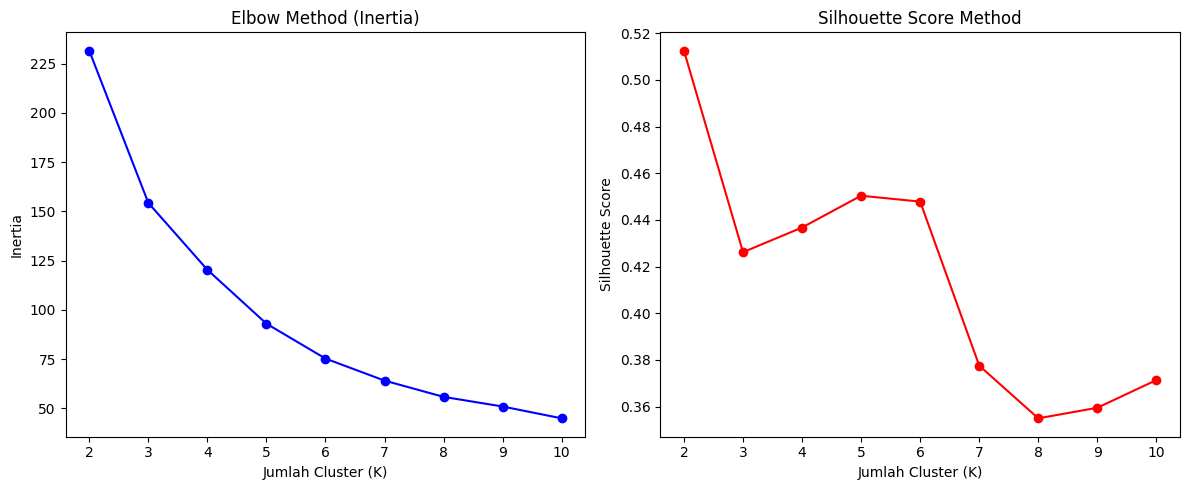

--- Memilih K=3 berdasarkan Elbow & Silhouette tertinggi ---


In [2]:
# =================================================================
# MENENTUKAN K OPTIMAL (ELBOW & SILHOUETTE)
# =================================================================
inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled)
    inertia_list.append(kmeans_temp.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))

# Visualisasi Elbow & Silhouette
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_list, marker='o', color='blue')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')

# Plot Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_list, marker='o', color='red')
plt.title('Silhouette Score Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Berdasarkan grafik, kita pilih K=3 (Titik sikut yang jelas & Score Silhouette tinggi)
k_optimal = 3
print(f"--- Memilih K={k_optimal} berdasarkan Elbow & Silhouette tertinggi ---")


Sebelum melakukan segmen akhir, kita perlu menentukan berapa banyak kelompok (K) yang paling pas. Pada program ini saya menggunakan dua metode yaitu: Elbow Method yang digunakan untuk mencari titik sikut/patahan pada grafik inertia dan metode Silhouette score yang digunakan untuk mencari nilai tertinggi untuk melihat seberapa baik data terpisah antar cluster.
Hasil outputnya bahwa Grafik elbow mwnunjukkan penurunan drastis hingga angka 3, yang kemudian melandai (membentuk sikut). Sedangkan grafik Silhouette juga menunjukkan nilai yang cukup tinggi pada K=3. Oleh karena itu, jumlh cluster sebanyak 3 dipilih sebagai nilai paling optimal.


--- PROFIL RINGKAS TIAP CLUSTER ---
                     total_bill       tip
segment_name                             
Budget Conscious      12.775464  1.883608
Potential Loyalists   20.732110  3.229908
High-Value Spenders   34.967105  5.179211


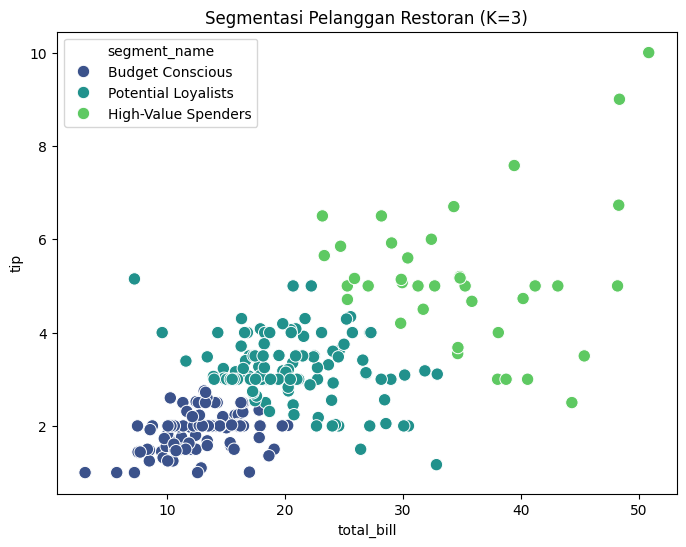

In [3]:
# =================================================================
# 2 & 3. CLUSTERING & PROFILING (PENAMAAN SEGMEN)
# =================================================================
final_kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = final_kmeans.fit_predict(X_scaled)

# Menghitung profil rata-rata tiap cluster
profile = df.groupby('cluster')[['total_bill', 'tip']].mean()

# Fungsi penamaan segmen (Nomor 3)
def berikan_nama(cluster_id):
    row = profile.loc[cluster_id]
    if row['total_bill'] > 28:
        return "High-Value Spenders"
    elif row['total_bill'] < 16:
        return "Budget Conscious"
    else:
        return "Potential Loyalists"

df['segment_name'] = df['cluster'].apply(berikan_nama)

print("\n--- PROFIL RINGKAS TIAP CLUSTER ---")
summary = df.groupby('segment_name')[['total_bill', 'tip']].mean().sort_values('total_bill')
print(summary)

# Visualisasi Hasil Akhir
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='segment_name', palette='viridis', s=80)
plt.title(f'Segmentasi Pelanggan Restoran (K={k_optimal})')
plt.show()

Setelah mendapatkan K=3, program melatih model final dan memasukkan setiap pelanggan ke dalam cluster yang sesuai. Saya juga membuat fungsi otomatis untuk memberikan nama segmen berdasarkan niai rata - rata tagihan mereka (High-value Spenders, Potential Loyalists, dan Budget Conscious).
Hasil outputnya yaitu berupa tbel ringkasan rata - rata pengeluaran dan sebuah scattetplot. Grafik tersebut menunjukkan pemisahan yang jelas antara tiga segmen pelanggan. Kita bisa melihat kelompok pelanggan mana yang sangat royal memberikan tip dan mana yang lebh heat dalam memesan menu.

In [4]:
# =================================================================
# 4. REKOMENDASI BISNIS
# =================================================================
print("\n--- REKOMENDASI BISNIS ---")
rekomendasi = {
    "High-Value Spenders": "Berikan layanan VIP dan prioritas reservasi. Kelompok ini adalah sumber profit utama, tawarkan menu premium atau wine eksklusif.",
    "Potential Loyalists": "Lakukan strategi upselling. Sarankan menu pembuka (appetizer) atau dessert untuk meningkatkan nilai transaksi mereka ke arah segmen high-value.",
    "Budget Conscious": "Fokus pada volume transaksi di jam sepi (off-peak). Tawarkan paket makan siang hemat atau Happy Hour agar operasional tetap produktif."
}

for segmen, saran in rekomendasi.items():
    print(f"- [{segmen}]: {saran}")


--- REKOMENDASI BISNIS ---
- [High-Value Spenders]: Berikan layanan VIP dan prioritas reservasi. Kelompok ini adalah sumber profit utama, tawarkan menu premium atau wine eksklusif.
- [Potential Loyalists]: Lakukan strategi upselling. Sarankan menu pembuka (appetizer) atau dessert untuk meningkatkan nilai transaksi mereka ke arah segmen high-value.
- [Budget Conscious]: Fokus pada volume transaksi di jam sepi (off-peak). Tawarkan paket makan siang hemat atau Happy Hour agar operasional tetap produktif.


Pada bagian akhir program ini yaitu digunakan untuk menerjemahkan hasil analisis data menjadi tindakan nyata bagi pemilik restoran.
Hasil outputnya yaitu memberikan instruksi spesifik untuk setiap segmen. Misalnya digunakan untuk segmen Budget Conscious, rekomendasi difokuskan pada promo jam makan siang hemat untuk menjaga tingkat kunjungan di waktu sepi.

#Kesimpulan
Berdasarkan hasil dari analisis clustering di atas, dapat saya simpulkan bahwa pelanggan restoran terbagi menjadi tiga segmen utama yang memiliki karakteristik transaksi berbeda. Penggunaan K-Means dengan bantuan metode Elboe dan Silhourtte memudahkan kita dalam menemukan jumlah pengelompokkan yang paling akurat. Dengan memahami profit dari masing - masing segmen (dari pengeluaran rendah hingga tinggi), dimana oihak manajemen dapat menerapkan strategi pemasaran yang lebih tepat sasarna gunauntuk memaksimalkan pendapatan restorannya.